In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


# print(torch.cuda.is_available())
torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)


cpu


In [2]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        out = self.network(x)
        
        # Extract components
        u = out[:, 0:1]
        v = out[:, 1:2]
        p_norm = out[:, 2:3]
        p_physical = p_norm * 9810.0 
        
        return torch.cat([u, v, p_physical], dim=1)
    
    
model = PINN().to(device)
test_pnts = torch.tensor([[0.2, 1.2, 0.5]], dtype=torch.float32, device=device)

pred = model(test_pnts)
print(pred)


# [CHANGED] Optional: load a checkpoint produced by THIS corrected notebook.
# The old 'pinn_model_02.pt' must NOT be used - it was trained on a different (wrong) problem.
LOAD_CHECKPOINT = True
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\updated_gravity_with_eddy\pinn_model_03_gravity_with_eddy_03_07.pt"
RUN_TRAINING = False

if (not RUN_TRAINING) and LOAD_CHECKPOINT and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    assert checkpoint.get("flow_mode") == "gravity", "checkpoint was not trained for the gravity-driven problem"
    model = PINN().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    loss_history = checkpoint["loss_history"]
    loss_components_history = checkpoint.get("loss_components_history", [])
    model_is_trained = True
    print(f"Loaded {checkpoint_path}  (epochs = {checkpoint['epoch']})")
elif not RUN_TRAINING:
    print(f"No checkpoint '{checkpoint_path}' found -> model is UNTRAINED (random weights).")

tensor([[ 2.8774e-02,  2.3928e-02, -3.6798e+02]], grad_fn=<CatBackward0>)
Loaded C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\updated_gravity_with_eddy\pinn_model_03_gravity_with_eddy_03_07.pt  (epochs = 15958)


C:\Users\ps302\AppData\Local\Temp\ipykernel_9812\2974998138.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

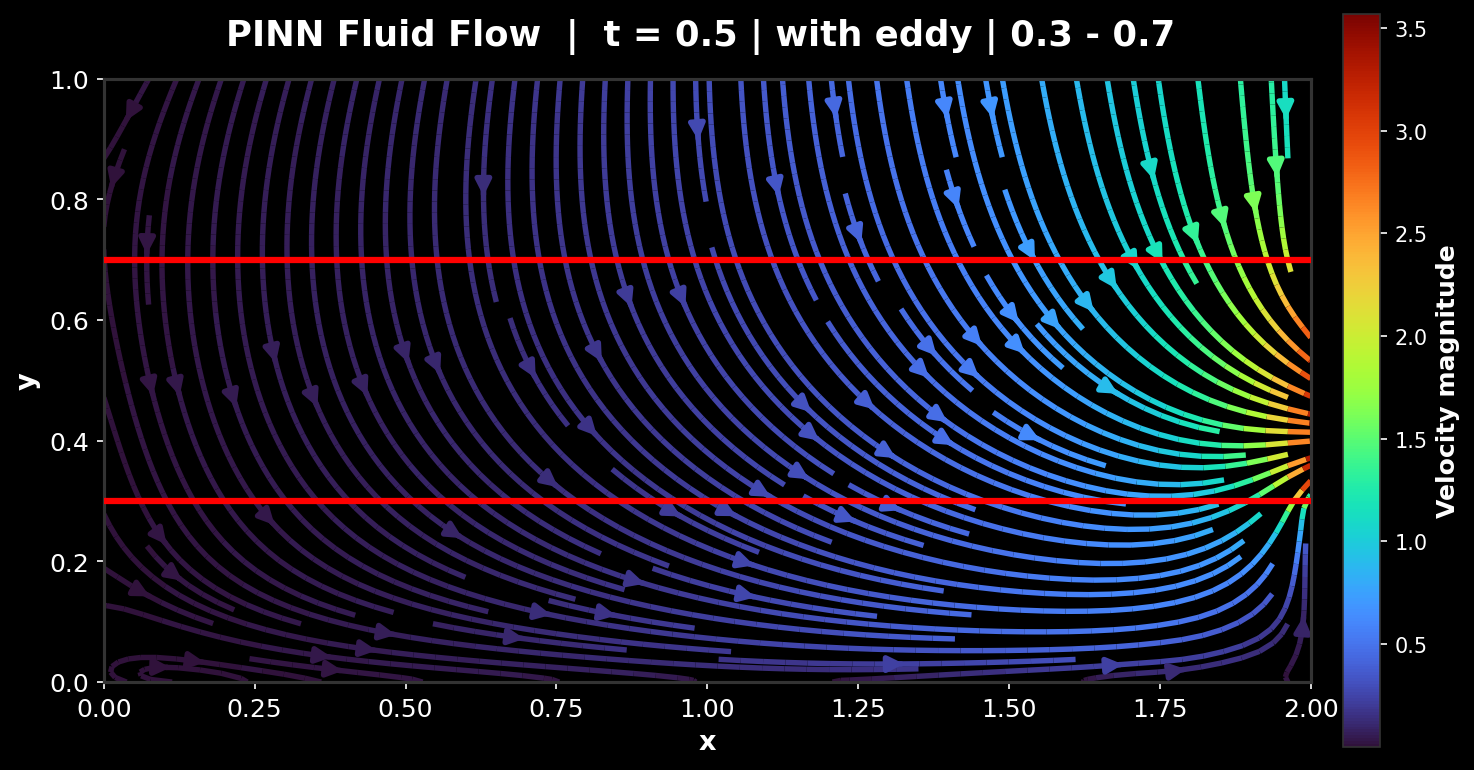

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 0.5

X, Y = np.meshgrid(x, y)

x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)

grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)

u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)

# Velocity magnitude: |V| = sqrt(u^2 + v^2)
velocity_magnitude = np.hypot(u_open, v_open)

# Global parameters updated for a dark theme
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Pure black backgrounds to make lines pop
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

stream = ax.streamplot(
    X,
    Y,
    u_open,
    v_open,
    color=velocity_magnitude,
    cmap="turbo", # 'turbo' acts as a brilliant neon on pure black
    norm=Normalize(
        vmin=velocity_magnitude.min(),
        vmax=velocity_magnitude.max()
    ),
    density=1.8,
    linewidth=2.6,
    arrowsize=1.5,
    minlength=0.12
)

# Subtle border to frame the plot without distracting from the data
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.5)

cbar = fig.colorbar(
    stream.lines,
    ax=ax,
    pad=0.025,
    fraction=0.045
)

cbar.set_label(
    "Velocity magnitude",
    fontsize=12,
    fontweight="bold",
    color="white"
)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor('#333333')

ax.set_xlabel("x", fontsize=13, fontweight="bold", color="white")
ax.set_ylabel("y", fontsize=13, fontweight="bold", color="white")

ax.set_title(
    f"PINN Fluid Flow  |  t = {t_plot} | with eddy | 0.3 - 0.7 ",
    fontsize=17,
    fontweight="bold",
    color="white",
    pad=16
)


# List of y-coordinates you want to plot
y_lines = [0.3, 0.7]

for y_val in y_lines:
    ax.axhline(
        y=y_val,
        color="red",
        linewidth=3,
        linestyle="-",
        label=f"y = {y_val}",
        zorder=10
    )

# Optional: To avoid duplicate legend labels if you have many lines,
# you can call ax.legend() after this to display the labels.

ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(False)

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import torch


def calculate_flow_rate(
    model,
    device,
    time_value,
    x_position=1.0,
    n_points=500
):
    y_values = np.linspace(0.0, 1.0, n_points)
    x_values = np.full_like(y_values, x_position)
    t_values = np.full_like(y_values, time_value)

    input_points = np.column_stack([
        x_values,
        y_values,
        t_values
    ])

    input_tensor = torch.tensor(
        input_points,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        prediction = model(input_tensor)

    # x-direction velocity
    u_values = prediction[:, 0].cpu().numpy()

    # Flow rate magnitude: | integral(u dy) |
    Q_magnitude = abs(np.trapezoid(u_values, y_values))

    return Q_magnitude


time_values = [0.0, 0.25, 0.5, 0.75, 1]

q_values = {}

for time_value in time_values:
    Q_magnitude = calculate_flow_rate(
        model=model,
        device=device,
        time_value=time_value,
        x_position=1.0,
        n_points=500
    )

    q_values[time_value] = Q_magnitude

    print(
        f"t = {time_value:.2f}, "
        f"|Q| = {Q_magnitude:.6f} m²/s"
    )

t = 0.00, |Q| = 0.000805 m²/s
t = 0.25, |Q| = 0.119031 m²/s
t = 0.50, |Q| = 0.124349 m²/s
t = 0.75, |Q| = 0.105113 m²/s
t = 1.00, |Q| = 0.083952 m²/s


### 0.3 - 0.8

In [56]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        out = self.network(x)
        
        # Extract components
        u = out[:, 0:1]
        v = out[:, 1:2]
        p_norm = out[:, 2:3]
        p_physical = p_norm * 9810.0 
        
        return torch.cat([u, v, p_physical], dim=1)
    
    
model = PINN().to(device)
test_pnts = torch.tensor([[0.2, 1.2, 0.5]], dtype=torch.float32, device=device)

pred = model(test_pnts)
print(pred)


# [CHANGED] Optional: load a checkpoint produced by THIS corrected notebook.
# The old 'pinn_model_02.pt' must NOT be used - it was trained on a different (wrong) problem.
LOAD_CHECKPOINT = True
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\updated_gravity_with_eddy\pinn_model_03_gravity_with_eddy_03_08.pt"
RUN_TRAINING = False

if (not RUN_TRAINING) and LOAD_CHECKPOINT and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    assert checkpoint.get("flow_mode") == "gravity", "checkpoint was not trained for the gravity-driven problem"
    model = PINN().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    loss_history = checkpoint["loss_history"]
    loss_components_history = checkpoint.get("loss_components_history", [])
    model_is_trained = True
    print(f"Loaded {checkpoint_path}  (epochs = {checkpoint['epoch']})")
elif not RUN_TRAINING:
    print(f"No checkpoint '{checkpoint_path}' found -> model is UNTRAINED (random weights).")

tensor([[-7.4136e-03,  1.0335e-02,  2.3076e+03]], grad_fn=<CatBackward0>)
Loaded C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\updated_gravity_with_eddy\pinn_model_03_gravity_with_eddy_03_08.pt  (epochs = 15796)


C:\Users\ps302\AppData\Local\Temp\ipykernel_27464\1321654542.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devic

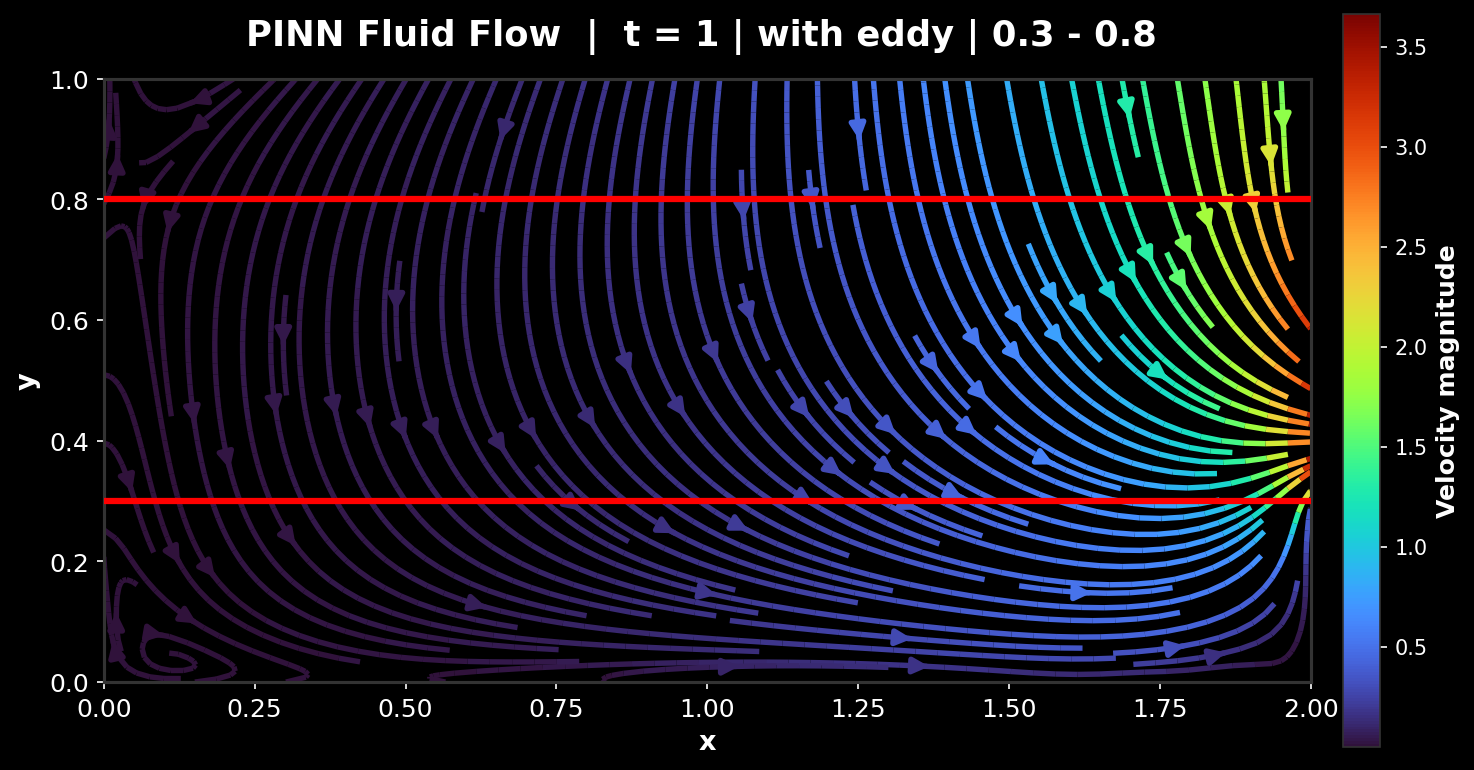

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)

x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)

grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)

u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)

# Velocity magnitude: |V| = sqrt(u^2 + v^2)
velocity_magnitude = np.hypot(u_open, v_open)

# Global parameters updated for a dark theme
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Pure black backgrounds to make lines pop
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

stream = ax.streamplot(
    X,
    Y,
    u_open,
    v_open,
    color=velocity_magnitude,
    cmap="turbo", # 'turbo' acts as a brilliant neon on pure black
    norm=Normalize(
        vmin=velocity_magnitude.min(),
        vmax=velocity_magnitude.max()
    ),
    density=1.8,
    linewidth=2.6,
    arrowsize=1.5,
    minlength=0.12
)

# Subtle border to frame the plot without distracting from the data
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.5)

cbar = fig.colorbar(
    stream.lines,
    ax=ax,
    pad=0.025,
    fraction=0.045
)

cbar.set_label(
    "Velocity magnitude",
    fontsize=12,
    fontweight="bold",
    color="white"
)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor('#333333')

ax.set_xlabel("x", fontsize=13, fontweight="bold", color="white")
ax.set_ylabel("y", fontsize=13, fontweight="bold", color="white")

ax.set_title(
    f"PINN Fluid Flow  |  t = {t_plot} | with eddy | 0.3 - 0.8 ",
    fontsize=17,
    fontweight="bold",
    color="white",
    pad=16
)


# List of y-coordinates you want to plot
y_lines = [0.3, 0.8]

for y_val in y_lines:
    ax.axhline(
        y=y_val,
        color="red",
        linewidth=3,
        linestyle="-",
        label=f"y = {y_val}",
        zorder=10
    )


ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(False)

plt.tight_layout()
plt.show()

In [62]:
import numpy as np
import torch


def calculate_flow_rate(
    model,
    device,
    time_value,
    x_position=1.0,
    n_points=500
):
    y_values = np.linspace(0.0, 1.0, n_points)
    x_values = np.full_like(y_values, x_position)
    t_values = np.full_like(y_values, time_value)

    input_points = np.column_stack([
        x_values,
        y_values,
        t_values
    ])

    input_tensor = torch.tensor(
        input_points,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        prediction = model(input_tensor)

    # x-direction velocity
    u_values = prediction[:, 0].cpu().numpy()

    # Flow rate magnitude: | integral(u dy) |
    Q_magnitude = abs(np.trapezoid(u_values, y_values))

    return Q_magnitude


time_values = [0.0, 0.25, 0.5, 0.75, 0.1]

q_values = {}

for time_value in time_values:
    Q_magnitude = calculate_flow_rate(
        model=model,
        device=device,
        time_value=time_value,
        x_position=1.0,
        n_points=500
    )

    q_values[time_value] = Q_magnitude

    print(
        f"t = {time_value:.2f}, "
        f"|Q| = {Q_magnitude:.6f} m²/s"
    )

t = 0.00, |Q| = 0.000108 m²/s
t = 0.25, |Q| = 0.133511 m²/s
t = 0.50, |Q| = 0.135604 m²/s
t = 0.75, |Q| = 0.105514 m²/s
t = 0.10, |Q| = 0.077790 m²/s


### 0.3 - 0.9

In [63]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        out = self.network(x)
        
        # Extract components
        u = out[:, 0:1]
        v = out[:, 1:2]
        p_norm = out[:, 2:3]
        p_physical = p_norm * 9810.0 
        
        return torch.cat([u, v, p_physical], dim=1)
    
    
model = PINN().to(device)
test_pnts = torch.tensor([[0.2, 1.2, 0.5]], dtype=torch.float32, device=device)

pred = model(test_pnts)
print(pred)


# [CHANGED] Optional: load a checkpoint produced by THIS corrected notebook.
# The old 'pinn_model_02.pt' must NOT be used - it was trained on a different (wrong) problem.
LOAD_CHECKPOINT = True
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\updated_gravity_with_eddy\pinn_model_03_gravity_with_eddy_03_09.pt"
RUN_TRAINING = False

if (not RUN_TRAINING) and LOAD_CHECKPOINT and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    assert checkpoint.get("flow_mode") == "gravity", "checkpoint was not trained for the gravity-driven problem"
    model = PINN().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    loss_history = checkpoint["loss_history"]
    loss_components_history = checkpoint.get("loss_components_history", [])
    model_is_trained = True
    print(f"Loaded {checkpoint_path}  (epochs = {checkpoint['epoch']})")
elif not RUN_TRAINING:
    print(f"No checkpoint '{checkpoint_path}' found -> model is UNTRAINED (random weights).")

tensor([[ 7.9935e-02,  2.2604e-01, -1.0011e+03]], grad_fn=<CatBackward0>)
Loaded C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\updated_gravity_with_eddy\pinn_model_03_gravity_with_eddy_03_09.pt  (epochs = 15822)


C:\Users\ps302\AppData\Local\Temp\ipykernel_27464\964107403.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

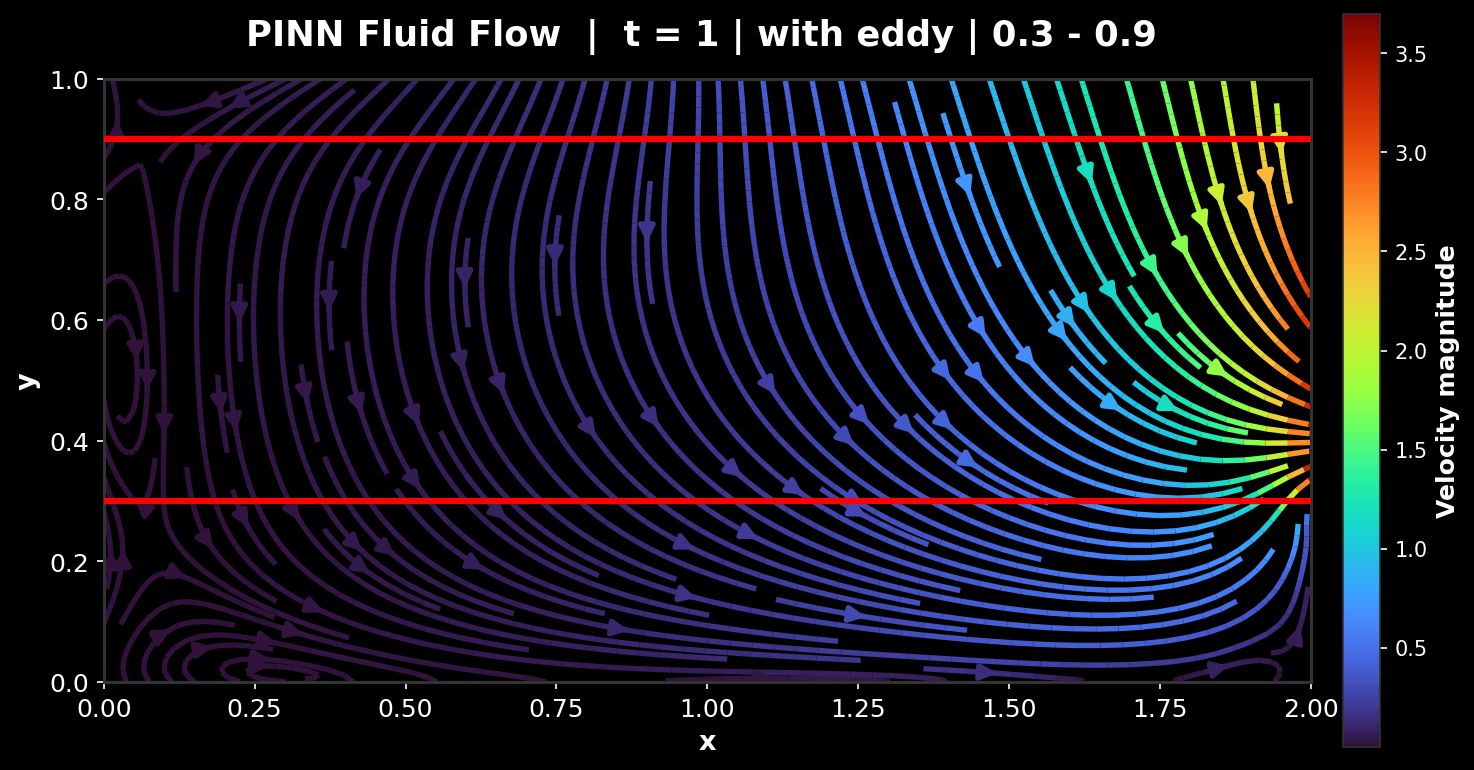

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)

x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)

grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)

u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)

# Velocity magnitude: |V| = sqrt(u^2 + v^2)
velocity_magnitude = np.hypot(u_open, v_open)

# Global parameters updated for a dark theme
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Pure black backgrounds to make lines pop
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

stream = ax.streamplot(
    X,
    Y,
    u_open,
    v_open,
    color=velocity_magnitude,
    cmap="turbo", # 'turbo' acts as a brilliant neon on pure black
    norm=Normalize(
        vmin=velocity_magnitude.min(),
        vmax=velocity_magnitude.max()
    ),
    density=1.8,
    linewidth=2.6,
    arrowsize=1.5,
    minlength=0.12
)

# Subtle border to frame the plot without distracting from the data
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.5)

cbar = fig.colorbar(
    stream.lines,
    ax=ax,
    pad=0.025,
    fraction=0.045
)

cbar.set_label(
    "Velocity magnitude",
    fontsize=12,
    fontweight="bold",
    color="white"
)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor('#333333')

ax.set_xlabel("x", fontsize=13, fontweight="bold", color="white")
ax.set_ylabel("y", fontsize=13, fontweight="bold", color="white")

ax.set_title(
    f"PINN Fluid Flow  |  t = {t_plot} | with eddy | 0.3 - 0.9 ",
    fontsize=17,
    fontweight="bold",
    color="white",
    pad=16
)


# List of y-coordinates you want to plot
y_lines = [0.3, 0.9]

for y_val in y_lines:
    ax.axhline(
        y=y_val,
        color="red",
        linewidth=3,
        linestyle="-",
        label=f"y = {y_val}",
        zorder=10
    )

# Optional: To avoid duplicate legend labels if you have many lines,
# you can call ax.legend() after this to display the labels.

ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(False)

plt.tight_layout()
plt.show()

In [70]:
import numpy as np
import torch


def calculate_flow_rate(
    model,
    device,
    time_value,
    x_position=1.0,
    n_points=500
):
    y_values = np.linspace(0.0, 1.0, n_points)
    x_values = np.full_like(y_values, x_position)
    t_values = np.full_like(y_values, time_value)

    input_points = np.column_stack([
        x_values,
        y_values,
        t_values
    ])

    input_tensor = torch.tensor(
        input_points,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        prediction = model(input_tensor)

    # x-direction velocity
    u_values = prediction[:, 0].cpu().numpy()

    # Flow rate magnitude: | integral(u dy) |
    Q_magnitude = abs(np.trapezoid(u_values, y_values))

    return Q_magnitude


time_values = [0.0, 0.25, 0.5, 0.75, 0.1]

q_values = {}

for time_value in time_values:
    Q_magnitude = calculate_flow_rate(
        model=model,
        device=device,
        time_value=time_value,
        x_position=1.0,
        n_points=500
    )

    q_values[time_value] = Q_magnitude

    print(
        f"t = {time_value:.2f}, "
        f"|Q| = {Q_magnitude:.6f} m²/s"
    )

t = 0.00, |Q| = 0.000586 m²/s
t = 0.25, |Q| = 0.128032 m²/s
t = 0.50, |Q| = 0.128460 m²/s
t = 0.75, |Q| = 0.101772 m²/s
t = 0.10, |Q| = 0.074691 m²/s


### 0.1 - 0.7

In [71]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        out = self.network(x)
        
        # Extract components
        u = out[:, 0:1]
        v = out[:, 1:2]
        p_norm = out[:, 2:3]
        p_physical = p_norm * 9810.0 
        
        return torch.cat([u, v, p_physical], dim=1)
    
    
model = PINN().to(device)
test_pnts = torch.tensor([[0.2, 1.2, 0.5]], dtype=torch.float32, device=device)

pred = model(test_pnts)
print(pred)


# [CHANGED] Optional: load a checkpoint produced by THIS corrected notebook.
# The old 'pinn_model_02.pt' must NOT be used - it was trained on a different (wrong) problem.
LOAD_CHECKPOINT = True
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\updated_gravity_with_eddy\pinn_model_03_gravity_with_eddy_01_07.pt"
RUN_TRAINING = False

if (not RUN_TRAINING) and LOAD_CHECKPOINT and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    assert checkpoint.get("flow_mode") == "gravity", "checkpoint was not trained for the gravity-driven problem"
    model = PINN().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    loss_history = checkpoint["loss_history"]
    loss_components_history = checkpoint.get("loss_components_history", [])
    model_is_trained = True
    print(f"Loaded {checkpoint_path}  (epochs = {checkpoint['epoch']})")
elif not RUN_TRAINING:
    print(f"No checkpoint '{checkpoint_path}' found -> model is UNTRAINED (random weights).")

tensor([[ 9.7427e-02, -6.0363e-02, -7.3237e+02]], grad_fn=<CatBackward0>)
Loaded C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\updated_gravity_with_eddy\pinn_model_03_gravity_with_eddy_01_07.pt  (epochs = 15833)


C:\Users\ps302\AppData\Local\Temp\ipykernel_27464\3333989147.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devic

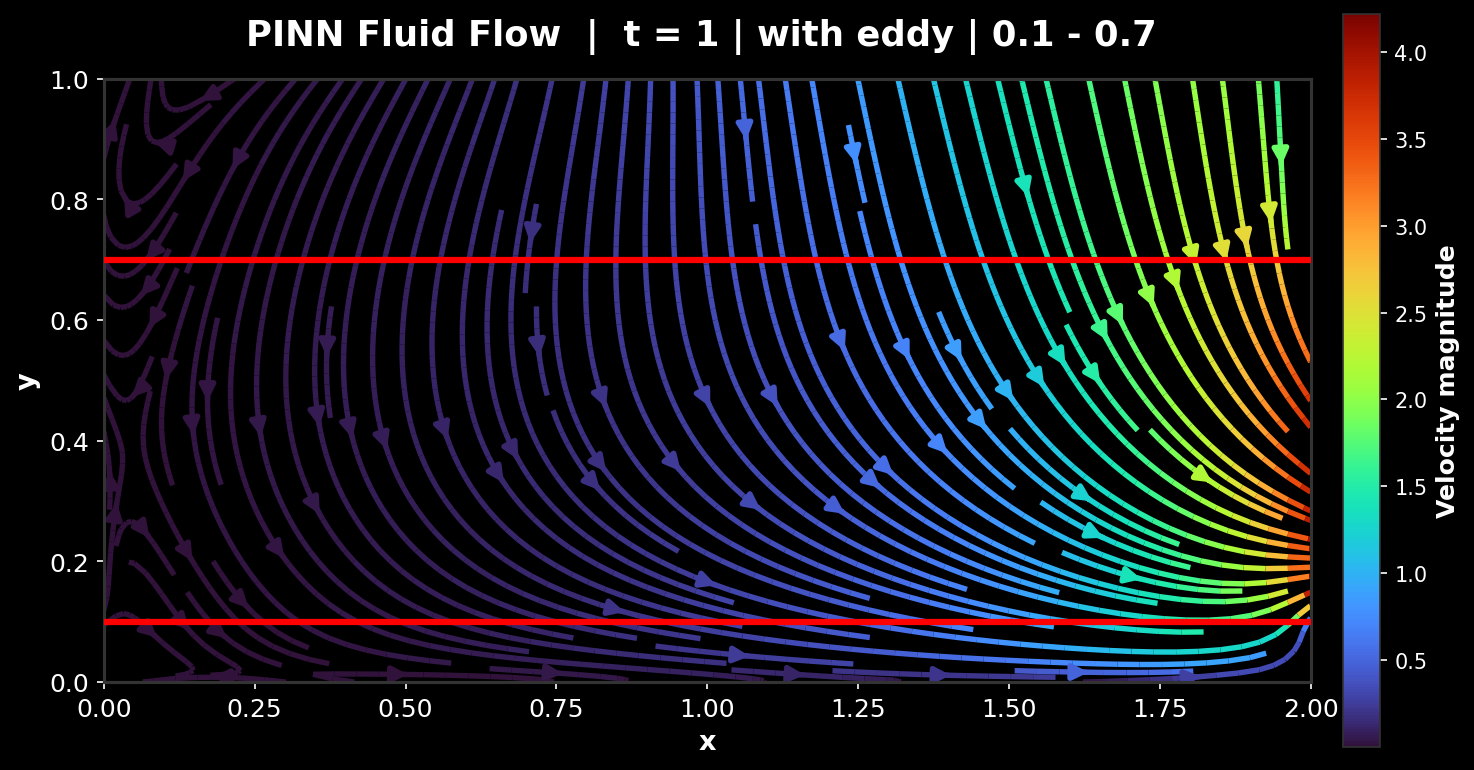

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)

x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)

grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)

u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)

# Velocity magnitude: |V| = sqrt(u^2 + v^2)
velocity_magnitude = np.hypot(u_open, v_open)

# Global parameters updated for a dark theme
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Pure black backgrounds to make lines pop
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

stream = ax.streamplot(
    X,
    Y,
    u_open,
    v_open,
    color=velocity_magnitude,
    cmap="turbo", # 'turbo' acts as a brilliant neon on pure black
    norm=Normalize(
        vmin=velocity_magnitude.min(),
        vmax=velocity_magnitude.max()
    ),
    density=1.8,
    linewidth=2.6,
    arrowsize=1.5,
    minlength=0.12
)

# Subtle border to frame the plot without distracting from the data
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.5)

cbar = fig.colorbar(
    stream.lines,
    ax=ax,
    pad=0.025,
    fraction=0.045
)

cbar.set_label(
    "Velocity magnitude",
    fontsize=12,
    fontweight="bold",
    color="white"
)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor('#333333')

ax.set_xlabel("x", fontsize=13, fontweight="bold", color="white")
ax.set_ylabel("y", fontsize=13, fontweight="bold", color="white")

ax.set_title(
    f"PINN Fluid Flow  |  t = {t_plot} | with eddy | 0.1 - 0.7 ",
    fontsize=17,
    fontweight="bold",
    color="white",
    pad=16
)


# List of y-coordinates you want to plot
y_lines = [0.1, 0.7]

for y_val in y_lines:
    ax.axhline(
        y=y_val,
        color="red",
        linewidth=3,
        linestyle="-",
        label=f"y = {y_val}",
        zorder=10
    )

# Optional: To avoid duplicate legend labels if you have many lines,
# you can call ax.legend() after this to display the labels.

ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(False)

plt.tight_layout()
plt.show()

In [77]:
import numpy as np
import torch


def calculate_flow_rate(
    model,
    device,
    time_value,
    x_position=1.0,
    n_points=500
):
    y_values = np.linspace(0.0, 1.0, n_points)
    x_values = np.full_like(y_values, x_position)
    t_values = np.full_like(y_values, time_value)

    input_points = np.column_stack([
        x_values,
        y_values,
        t_values
    ])

    input_tensor = torch.tensor(
        input_points,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        prediction = model(input_tensor)

    # x-direction velocity
    u_values = prediction[:, 0].cpu().numpy()

    # Flow rate magnitude: | integral(u dy) |
    Q_magnitude = abs(np.trapezoid(u_values, y_values))

    return Q_magnitude


time_values = [0.0, 0.25, 0.5, 0.75, 0.1]

q_values = {}

for time_value in time_values:
    Q_magnitude = calculate_flow_rate(
        model=model,
        device=device,
        time_value=time_value,
        x_position=1.0,
        n_points=500
    )

    q_values[time_value] = Q_magnitude

    print(
        f"t = {time_value:.2f}, "
        f"|Q| = {Q_magnitude:.6f} m²/s"
    )

t = 0.00, |Q| = 0.000011 m²/s
t = 0.25, |Q| = 0.228498 m²/s
t = 0.50, |Q| = 0.222406 m²/s
t = 0.75, |Q| = 0.166453 m²/s
t = 0.10, |Q| = 0.130645 m²/s


### 0.2 - 0.7

In [78]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        out = self.network(x)
        
        # Extract components
        u = out[:, 0:1]
        v = out[:, 1:2]
        p_norm = out[:, 2:3]
        p_physical = p_norm * 9810.0 
        
        return torch.cat([u, v, p_physical], dim=1)
    
    
model = PINN().to(device)
test_pnts = torch.tensor([[0.2, 1.2, 0.5]], dtype=torch.float32, device=device)

pred = model(test_pnts)
print(pred)


# [CHANGED] Optional: load a checkpoint produced by THIS corrected notebook.
# The old 'pinn_model_02.pt' must NOT be used - it was trained on a different (wrong) problem.
LOAD_CHECKPOINT = True
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\updated_gravity_with_eddy\pinn_model_03_gravity_with_eddy_02_07.pt"
RUN_TRAINING = False

if (not RUN_TRAINING) and LOAD_CHECKPOINT and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    assert checkpoint.get("flow_mode") == "gravity", "checkpoint was not trained for the gravity-driven problem"
    model = PINN().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    loss_history = checkpoint["loss_history"]
    loss_components_history = checkpoint.get("loss_components_history", [])
    model_is_trained = True
    print(f"Loaded {checkpoint_path}  (epochs = {checkpoint['epoch']})")
elif not RUN_TRAINING:
    print(f"No checkpoint '{checkpoint_path}' found -> model is UNTRAINED (random weights).")

tensor([[ 3.1729e-02, -8.2846e-02,  1.2968e+03]], grad_fn=<CatBackward0>)
Loaded C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\updated_gravity_with_eddy\pinn_model_03_gravity_with_eddy_02_07.pt  (epochs = 15967)


C:\Users\ps302\AppData\Local\Temp\ipykernel_27464\4274630681.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devic

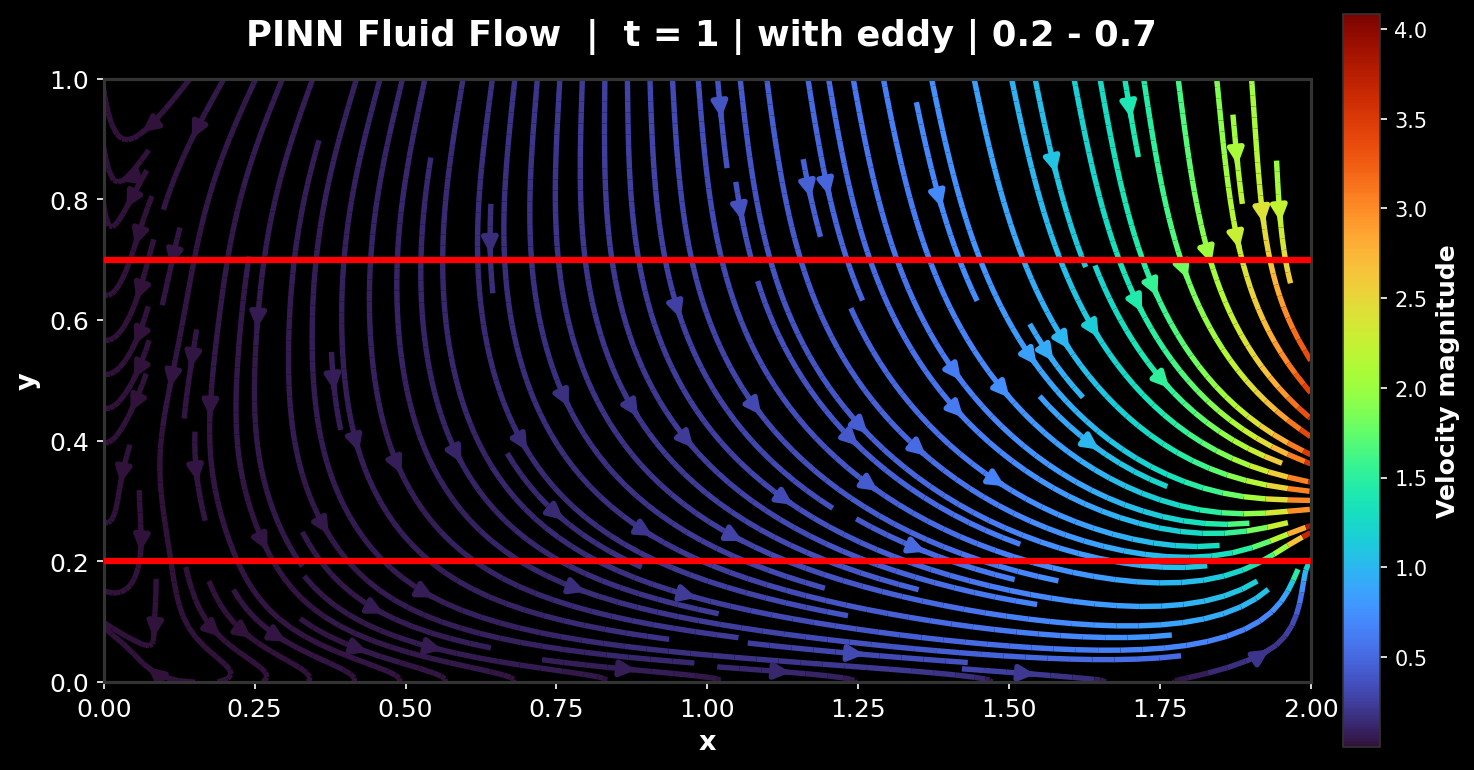

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)

x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)

grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)

u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)

# Velocity magnitude: |V| = sqrt(u^2 + v^2)
velocity_magnitude = np.hypot(u_open, v_open)

# Global parameters updated for a dark theme
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Pure black backgrounds to make lines pop
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

stream = ax.streamplot(
    X,
    Y,
    u_open,
    v_open,
    color=velocity_magnitude,
    cmap="turbo", # 'turbo' acts as a brilliant neon on pure black
    norm=Normalize(
        vmin=velocity_magnitude.min(),
        vmax=velocity_magnitude.max()
    ),
    density=1.8,
    linewidth=2.6,
    arrowsize=1.5,
    minlength=0.12
)

# Subtle border to frame the plot without distracting from the data
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.5)

cbar = fig.colorbar(
    stream.lines,
    ax=ax,
    pad=0.025,
    fraction=0.045
)

cbar.set_label(
    "Velocity magnitude",
    fontsize=12,
    fontweight="bold",
    color="white"
)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor('#333333')

ax.set_xlabel("x", fontsize=13, fontweight="bold", color="white")
ax.set_ylabel("y", fontsize=13, fontweight="bold", color="white")

ax.set_title(
    f"PINN Fluid Flow  |  t = {t_plot} | with eddy | 0.2 - 0.7 ",
    fontsize=17,
    fontweight="bold",
    color="white",
    pad=16
)


# List of y-coordinates you want to plot
y_lines = [0.2, 0.7]

for y_val in y_lines:
    ax.axhline(
        y=y_val,
        color="red",
        linewidth=3,
        linestyle="-",
        label=f"y = {y_val}",
        zorder=10
    )

# Optional: To avoid duplicate legend labels if you have many lines,
# you can call ax.legend() after this to display the labels.

ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(False)

plt.tight_layout()
plt.show()

In [84]:
import numpy as np
import torch


def calculate_flow_rate(
    model,
    device,
    time_value,
    x_position=1.0,
    n_points=500
):
    y_values = np.linspace(0.0, 1.0, n_points)
    x_values = np.full_like(y_values, x_position)
    t_values = np.full_like(y_values, time_value)

    input_points = np.column_stack([
        x_values,
        y_values,
        t_values
    ])

    input_tensor = torch.tensor(
        input_points,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        prediction = model(input_tensor)

    # x-direction velocity
    u_values = prediction[:, 0].cpu().numpy()

    # Flow rate magnitude: | integral(u dy) |
    Q_magnitude = abs(np.trapezoid(u_values, y_values))

    return Q_magnitude


time_values = [0.0, 0.25, 0.5, 0.75, 0.1]

q_values = {}

for time_value in time_values:
    Q_magnitude = calculate_flow_rate(
        model=model,
        device=device,
        time_value=time_value,
        x_position=1.0,
        n_points=500
    )

    q_values[time_value] = Q_magnitude

    print(
        f"t = {time_value:.2f}, "
        f"|Q| = {Q_magnitude:.6f} m²/s"
    )

t = 0.00, |Q| = 0.000419 m²/s
t = 0.25, |Q| = 0.179562 m²/s
t = 0.50, |Q| = 0.187393 m²/s
t = 0.75, |Q| = 0.158115 m²/s
t = 0.10, |Q| = 0.101660 m²/s
